# NR PRACH 设计原理与仿真

> 基于论文 *On the Design Details of SS/PBCH, Signal Generation and PRACH in 5G-NR*（Chakrapani, IEEE Access 2020）的 **Section IV (PRACH Design)** 与 **Section V (Important Aspects of PRACH Receiver Design)**，从基本原理仿真 NR PRACH 的关键技术。

本 notebook 围绕 **PRACH format A1（FR2 短序列）** 给出原理性说明并提供完整仿真。所有公用函数集中在 [`nr_init_access.py`](./nr_init_access.py)，正文聚焦概念与仿真组合。

1. **ZC 序列特性**：CAZAC、循环移位正交性、跨 root 互相关、循环移位 ↔ 时延等价关系
2. **A1 PRACH occasion 时频结构 + Cell-dimensioning**（重现论文 Table 2）
3. **完整 OFDM 采样率级 PRACH 链路** —— 多 UE 同 occasion 接入；相干 vs 非相干合并对比；接收机的两个相位补偿步骤（V-C 公共相位反补偿、V-D 数据 CP 相位斜坡补偿）
4. **多频域 occasion 并行接入**（M=2 FD occasions、6 UE 分两组）

贯穿全文：$L_{RA}=139$，$\Delta f_{RA}=120\text{ kHz}$，A1 short format，$N_{FFT}=1024$（FR2 100 MHz @ 120 kHz）。


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import nr_init_access as nr
from nr_init_access import (
    PRACH_FORMATS, zc_td, zc_fd, cyclic_shift, cyclic_xcorr,
    ofdm_modulate, ofdm_demodulate, tone_start_index,
    prach_tx, prach_channel, prach_rx_pdp,
    undo_common_phase, compensate_cp_phase_ramp,
    awgn, detect_peaks_per_zone, estimate_noise_var,
    cell_dimensioning, plot_pdp_with_zones, plot_prach_tf_schematic,
)

np.random.seed(42)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True

FMT = 'A1'
L_RA = PRACH_FORMATS[FMT]['L_RA']
DELTA_F_RA = 120e3
N_FFT = 1024
A1_DIM = cell_dimensioning('A1')
N_CS = A1_DIM['n_cs']
N_REP = PRACH_FORMATS[FMT]['n_seq']

print(f'format               = {FMT}')
print(f'L_RA                 = {L_RA}')
print(f'delta_f_RA           = {DELTA_F_RA/1e3:.0f} kHz')
print(f'N_FFT                = {N_FFT}')
print(f'CP samples (agg)     = {PRACH_FORMATS[FMT]["N_cp"]}')
print(f'SEQ repetitions      = {N_REP}')
print(f'N_CS (A1, FR2)       = {N_CS}')
print(f'cyclic shifts/root   = {A1_DIM["cv_per_root"]}')
print(f'roots for 64 preamb  = {A1_DIM["roots_needed"]}')


format               = A1
L_RA                 = 139
delta_f_RA           = 120 kHz
N_FFT                = 1024
CP samples (agg)     = 288
SEQ repetitions      = 2
N_CS (A1, FR2)       = 19
cyclic shifts/root   = 7
roots for 64 preamb  = 10


## 1. ZC 序列特性

NR PRACH 短前导格式中 ZC 序列在**时域**定义为：

$$x_u(n) = e^{-j \pi u n (n+1) / L_{RA}}, \quad n = 0, 1, \dots, L_{RA}-1$$

$u$ 是 *root sequence index*。$L_{RA}=139$ 是质数，因此 $\gcd(u, L_{RA})=1$ 对所有 $u\in[1,138]$ 成立，每个 $u$ 都能产生合法 ZC 序列。


### 1.1 频域恒包络 + OFDM 时域 PAPR

ZC 序列的核心性质是 **CAZAC**（Constant Amplitude Zero AutoCorrelation）：

- 时域恒包络：$|x_u(n)| = 1$
- 频域恒包络：$|y_u(k)| = \sqrt{L_{RA}}$，其中 $y_u = \mathrm{DFT}(x_u)$ 也是 ZC 序列

NR PRACH 发送链：(1) 把 $y_{u,v}$（length $L_{RA}$）当作子载波数据映射到 $L_{RA}$ 个 PRACH tones；(2) 在 $N_{FFT}$ 点 IFFT 中实现 OFDM 调制；(3) 加 CP 并重复 $N_\text{rep}$ 次（A1 取 2 次）。

频域恒包络 ⇒ 时域 OFDM 信号 PAPR 极低，对功放友好（接近恒包络的单载波）。


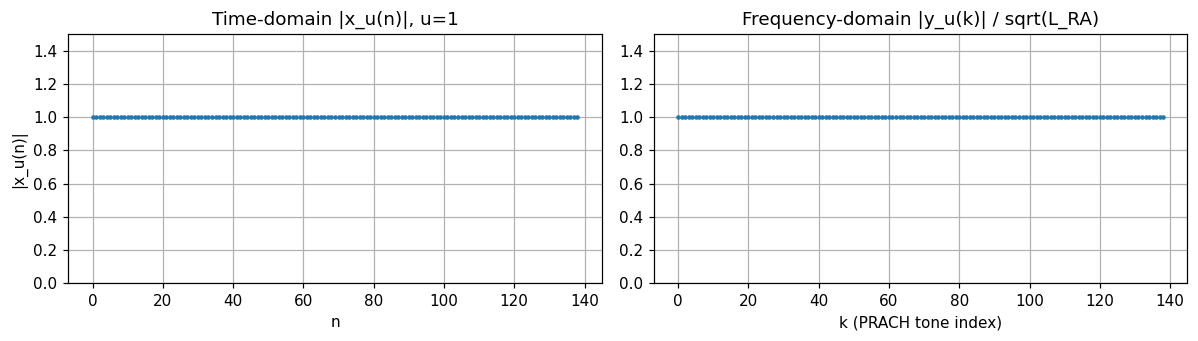

TD magnitude: mean=1.000000, std=7.88e-17
FD magnitude: mean=11.7898, std=1.31e-13


In [2]:
u = 1
xu_td = zc_td(u)
yu_fd = zc_fd(u)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].plot(np.abs(xu_td), 'o', markersize=2)
axes[0].set_title(f'Time-domain |x_u(n)|, u={u}')
axes[0].set_xlabel('n'); axes[0].set_ylabel('|x_u(n)|'); axes[0].set_ylim(0, 1.5)

axes[1].plot(np.abs(yu_fd) / np.sqrt(L_RA), 'o', markersize=2)
axes[1].set_title('Frequency-domain |y_u(k)| / sqrt(L_RA)')
axes[1].set_xlabel('k (PRACH tone index)'); axes[1].set_ylim(0, 1.5)
plt.tight_layout(); plt.show()

print(f'TD magnitude: mean={np.mean(np.abs(xu_td)):.6f}, std={np.std(np.abs(xu_td)):.2e}')
print(f'FD magnitude: mean={np.mean(np.abs(yu_fd)):.4f}, std={np.std(np.abs(yu_fd)):.2e}')


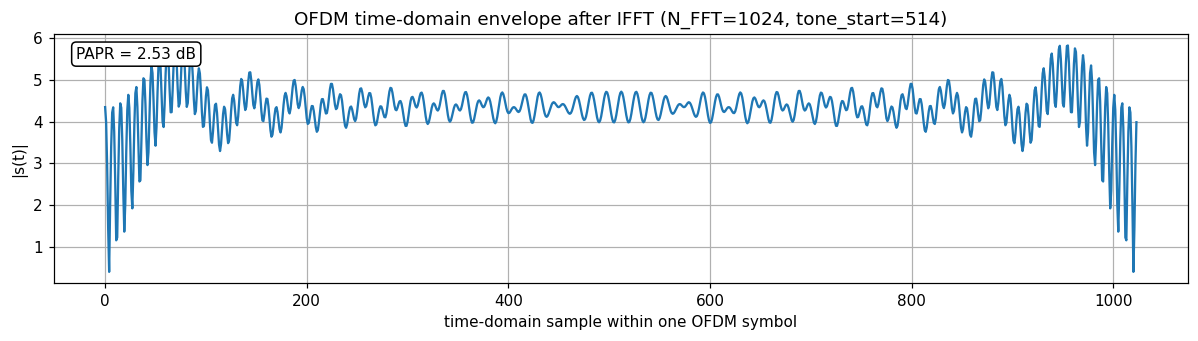

PAPR of PRACH OFDM symbol: 2.53 dB
(random QAM data PAPR is typically 10-12 dB; ZC is much lower thanks to CAZAC.)


In [3]:
# Drop the FD ZC into N_FFT-point OFDM and observe the time-domain envelope.
k_start = tone_start_index(N_FFT, k1=0, k_bar=2)
ofdm_time = ofdm_modulate(yu_fd, N_FFT, k_start, cp_len=0)
papr_db = 10 * np.log10(np.max(np.abs(ofdm_time)**2) / np.mean(np.abs(ofdm_time)**2))

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(np.abs(ofdm_time))
ax.set_xlabel('time-domain sample within one OFDM symbol'); ax.set_ylabel('|s(t)|')
ax.set_title(f'OFDM time-domain envelope after IFFT (N_FFT={N_FFT}, tone_start={k_start})')
ax.text(0.02, 0.95, f'PAPR = {papr_db:.2f} dB',
        transform=ax.transAxes, va='top',
        bbox=dict(boxstyle='round', facecolor='white'))
plt.tight_layout(); plt.show()

print(f'PAPR of PRACH OFDM symbol: {papr_db:.2f} dB')
print('(random QAM data PAPR is typically 10-12 dB; ZC is much lower thanks to CAZAC.)')


### 1.2 自相关与互相关

定义循环互相关：$r_{ab}[k] = \sum_n a[n]\, b^*[(n - k) \bmod L_{RA}]$。

**(a) 同一 root，不同 cyclic shift —— 完美正交**

对同 root 的两个 cyclic shift $C_{v_1}$、$C_{v_2}$，循环互相关是单脉冲，峰值在 $|C_{v_1}-C_{v_2}|\bmod L_{RA}$ 处；其他 lag 处理论上为 0。

**(b) 不同 root —— 互相关 $1/\sqrt{L_{RA}}$**

不同 root 的 ZC 序列之间归一化互相关在所有 lag 上接近 $1/\sqrt{L_{RA}}\approx 0.085$ ($L_{RA}=139$)。这就是同 cell 多 root 共存时引入的本底干扰水平。

**约定**：本笔记采用 `cyclic_shift(x, Cv) = np.roll(x, Cv)`，与"接收端做共轭相关后峰值出现在 $C_v+\tau$"的方向一致（$\tau$ 是传播延迟）。与论文 Eq.(11) 仅相差符号约定，物理结果不变。


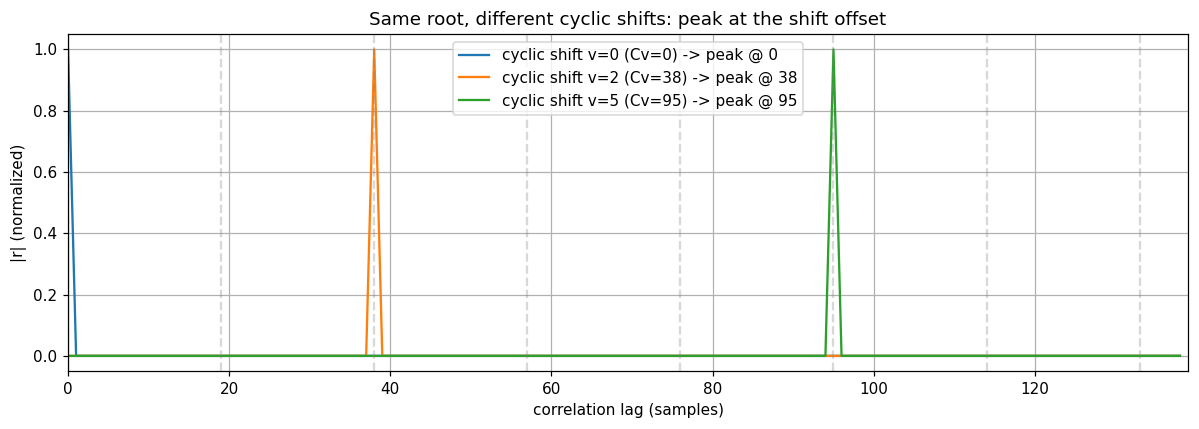

In [4]:
# (a) Same root, different cyclic shifts
v_list = [0, 2, 5]
fig, ax = plt.subplots(figsize=(11, 4))
for v in v_list:
    Cv = v * N_CS
    x_v = cyclic_shift(xu_td, Cv)
    r = cyclic_xcorr(x_v, xu_td)
    ax.plot(np.abs(r), label=f'cyclic shift v={v} (Cv={Cv}) -> peak @ {int(np.argmax(np.abs(r)))}')

for k in range(L_RA // N_CS + 1):
    ax.axvline(k * N_CS, color='gray', alpha=0.3, linestyle='--')

ax.set_xlabel('correlation lag (samples)'); ax.set_ylabel('|r| (normalized)')
ax.set_title('Same root, different cyclic shifts: peak at the shift offset')
ax.legend(); ax.set_xlim(0, L_RA)
plt.tight_layout(); plt.show()


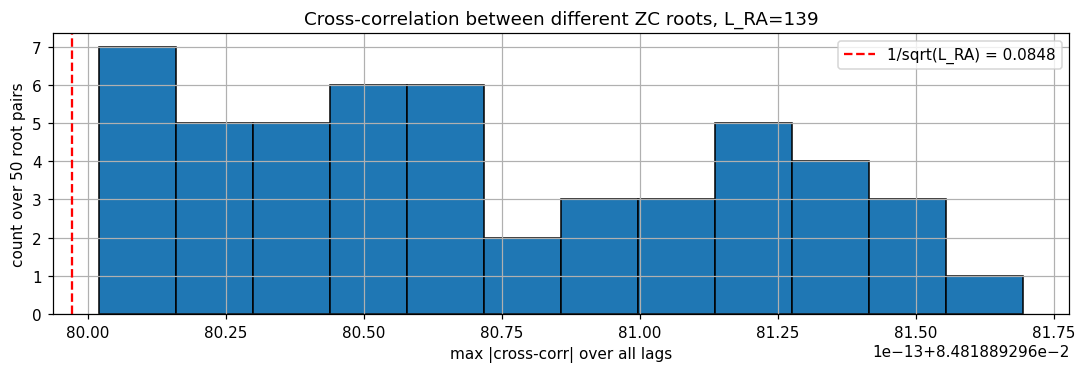

Empirical mean of max |xcorr|: 0.0848
Theoretical 1/sqrt(L_RA):     0.0848


In [5]:
# (b) Different roots: cross-correlation magnitude approaches 1/sqrt(L_RA).
ref = zc_td(1)
candidates = list(range(2, 52))   # 50 distinct roots
max_xc = [np.max(np.abs(cyclic_xcorr(zc_td(uu), ref))) for uu in candidates]
theoretical = 1 / np.sqrt(L_RA)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.hist(max_xc, bins=12, edgecolor='black')
ax.axvline(theoretical, color='red', linestyle='--',
           label=f'1/sqrt(L_RA) = {theoretical:.4f}')
ax.set_xlabel('max |cross-corr| over all lags'); ax.set_ylabel('count over 50 root pairs')
ax.set_title(f'Cross-correlation between different ZC roots, L_RA={L_RA}')
ax.legend()
plt.tight_layout(); plt.show()

print(f'Empirical mean of max |xcorr|: {np.mean(max_xc):.4f}')
print(f'Theoretical 1/sqrt(L_RA):     {theoretical:.4f}')


### 1.3 循环移位 ↔ 时延

UE 发送 $s(n)=$`cyclic_shift(x_u, Cv)`，传播延迟 $\tau$（PRACH 采样为单位）使接收信号变为 $r(n) = s(n - \tau)$。频域上 $R(k) = X_u(k)\, e^{-j2\pi k(C_v+\tau)/L_{RA}}$。

接收端做匹配 $R(k)\cdot X_u^*(k)$ 后 IFFT，**相关峰落在位置 $(C_v+\tau)\bmod L_{RA}$**。

**关键设计**：$N_{CS}$ 必须大于 cell 内最大可能的"等效时延"（来回传播 + 信道延扩）。每个 cyclic shift 对应一个长度 $N_{CS}$ 的 **zero-correlation zone (ZCZ)**：

- 峰值落在哪个 zone → UE 用了哪个 preamble
- 峰值在 zone 内的偏移 → UE 的传播时延 $\tau$

**时序分辨率**：直接用 $L_{RA}$ 点 IFFT 得到的时序分辨率为 $1/(L_{RA}\cdot\Delta f_{RA}) \approx 60$ ns；论文 V-E 建议 IFFT size $N_{IFFT}\ge L_{RA}$，例如 $N_{IFFT}=144$ 时分辨率为 $1/(N_{IFFT}\cdot\Delta f_{RA}) \approx 57.87$ ns，$N_{IFFT}=192$ 时约 43.4 ns。


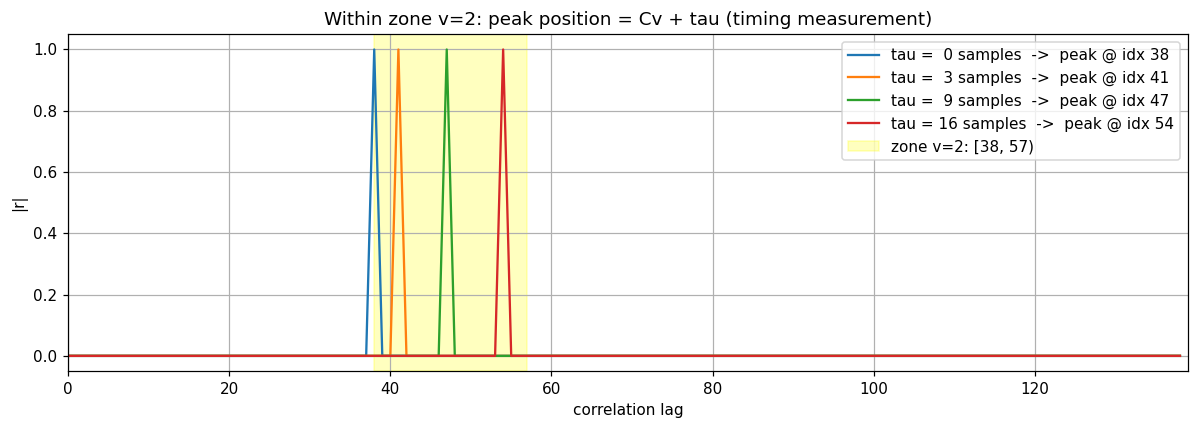

N_IFFT= 139: timing resolution = 59.95 ns
N_IFFT= 144: timing resolution = 57.87 ns
N_IFFT= 192: timing resolution = 43.40 ns
N_IFFT= 256: timing resolution = 32.55 ns


In [6]:
# UE picks Cv = v*N_CS, then propagation delay tau adds to peak position.
Cv = 2 * N_CS                    # UE picked preamble index v=2 (Cv=38)
tau_list = [0, 3, 9, 16]

fig, ax = plt.subplots(figsize=(11, 4))
x_v = cyclic_shift(xu_td, Cv)
for tau in tau_list:
    rx = np.roll(x_v, tau)                # propagation delay
    r = cyclic_xcorr(rx, xu_td)           # gNB correlates with unshifted root
    peak_idx = int(np.argmax(np.abs(r)))
    ax.plot(np.abs(r), label=f'tau = {tau:>2d} samples  ->  peak @ idx {peak_idx}')

ax.axvspan(Cv, Cv + N_CS, color='yellow', alpha=0.25,
           label=f'zone v=2: [{Cv}, {Cv+N_CS})')
ax.set_xlim(0, L_RA); ax.set_xlabel('correlation lag'); ax.set_ylabel('|r|')
ax.set_title('Within zone v=2: peak position = Cv + tau (timing measurement)')
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

# Print timing resolutions
for n_ifft in (L_RA, 144, 192, 256):
    res_ns = 1 / (n_ifft * DELTA_F_RA) * 1e9
    print(f'N_IFFT={n_ifft:>4d}: timing resolution = {res_ns:.2f} ns')


## 2. PRACH Format A1 时频结构

### 2.1 时域 occasion (TD occasion)

A1 短格式（论文 Table 6.3.3.1-2 / Figure 12）：
- 一个 TD occasion = **CP + 2 × SEQ**（$N_\text{rep}=2$，无 GT）
- 一个 PRACH slot 内可配置 **6 或 3** 个 TD occasions（μ=3, 120 kHz SCS, slot 长 125 μs）
- 多个 TD occasions 紧挨排布以提高接入容量

### 2.2 频域 occasion (FD occasion)

- 单 FD occasion 占 $K \cdot M_{RB} = 12$ PUSCH RBs；PRACH 实际带宽 $L_{RA} \cdot \Delta f_{RA}=139\times 120\,\text{kHz}=16.68$ MHz
- RRC 参数 `msg1-FDM` 配置 $M\in\{1,2,4,8\}$ 个 FD occasions，频率上**连续相邻**
- 同一 PRACH config 在所有 FD occasion 上的参数（root 集合、$N_{CS}$）相同

### 2.3 Cell-dimensioning (重现论文 Table 2)

按论文 Section IV-C-2 的四步流程（`nr_init_access.cell_dimensioning`）：

1. $N'_{CS} = \frac{N^{RA}_{CP}}{2048} \cdot L_{RA}$（A1: $288/2048 \times 139 = 19.55$）→ 在 Table 6.3.3.1-7 上量化到 $N_{CS}$
2. cyclic shifts per root $= \lfloor L_{RA}/N_{CS}\rfloor$
3. roots needed $= \lceil 64 / C_v \rceil$
4. cell radius $= (N_{CS}/(\Delta f_{RA}\cdot L_{RA}) - \tau_d/2^\mu)\cdot c/2$


In [7]:
# Reproduce paper Table 2 for short-format PRACH at mu=3 (FR2 120 kHz).
print(f'{"fmt":<5}{"N_CS_pr":>10}{"N_CS":>7}{"Cv":>5}{"roots":>7}{"radius_m":>11}')
print('-' * 45)
for fmt in ('A1', 'A2', 'A3', 'B1', 'B4', 'C0', 'C2'):
    d = cell_dimensioning(fmt, mu=3)
    print(f'{fmt:<5}{d["n_cs_prime"]:>10.2f}{d["n_cs"]:>7d}'
          f'{d["cv_per_root"]:>5d}{d["roots_needed"]:>7d}{d["cell_radius_m"]:>11.1f}')


fmt     N_CS_pr   N_CS   Cv  roots   radius_m
---------------------------------------------
A1        19.55     19    7     10       82.9
A2        39.09     34    4     16      217.8
A3        58.64     46    3     22      325.7
B1        14.66     13   10      7       29.0
B4        63.53     46    3     22      325.7
C0        84.16     69    2     32      532.6
C2       139.00     69    2     32      532.6


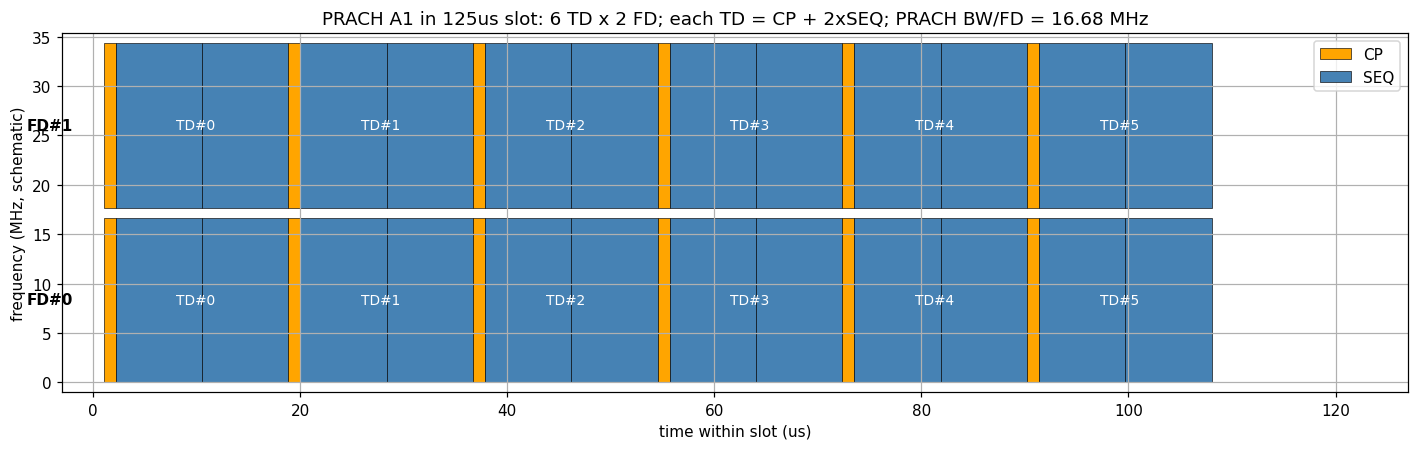

SEQ duration:           8.33 us = 1/delta_f_RA
A1 aggregate CP:        1.17 us (288 samples)
A1 TD occasion duration:17.84 us (CP + 2 x SEQ)
PRACH BW per FD:        16.68 MHz


In [8]:
# Schematic of PRACH A1 in one 125 us slot: 6 TD occasions x 2 FD occasions.
fig, ax = plt.subplots(figsize=(13, 4.2))
plot_prach_tf_schematic(fmt='A1', m_fd=2, n_td=6, slot_us=125.0, ax=ax)
plt.tight_layout(); plt.show()

# Print the underlying numbers
p = PRACH_FORMATS[FMT]
seq_us = 1e6 / DELTA_F_RA
cp_us = p['N_cp'] / (DELTA_F_RA * p['N_u']) * 1e6
print(f'SEQ duration:           {seq_us:.2f} us = 1/delta_f_RA')
print(f'A1 aggregate CP:        {cp_us:.2f} us ({p["N_cp"]} samples)')
print(f'A1 TD occasion duration:{cp_us + N_REP*seq_us:.2f} us (CP + {N_REP} x SEQ)')
print(f'PRACH BW per FD:        {L_RA*DELTA_F_RA/1e6:.2f} MHz')


## 3. 完整 OFDM 链路：同 occasion 多 UE 同时接入仿真

之前的 1.2 / 1.3 节为了说明数学等价关系直接在 $L_{RA}$ 采样率上做循环相关。本节升级到**真正的 OFDM 链路**——即 PRACH 在 100 MHz @ 120 kHz 的基带（$N_{FFT}=1024$, $f_s=122.88$ Msps）上跑完整的 TX/RX。

**TX (per UE k)**：
```
zc_fd[L_RA]  -> 子载波映射 (tone_start_index)  -> N_FFT IFFT  -> 单 SEQ 时域
重复 N_rep 次,                                  -> 取末尾 N_cp 个样本作 aggregate CP
拼成 [CP][SEQ_0][SEQ_1]...[SEQ_{N_rep-1}]      -> 加 cyclic_shift Cv (TD)
```

**Channel**：sample-level 整数时延 + AWGN（多 UE 叠加见 `prach_channel`）

**RX (BS, single antenna)**：
```
rx_td  -> 跳过 aggregate CP  -> 取出 N_rep 个 N_FFT 段
每段做 N_FFT FFT             -> 子载波抽取 L_RA tones (k_start = N_FFT/2 + K*k1 + k_bar)
                             -> 与 zc_fd[u_root] 共轭相乘
                             -> 每个 rep 做 N_IFFT IFFT
合并: 'noncoh' 是 |.|^2 求和；'coh' 是 FD/TD 复数和后再取 |.|^2
                             -> per-zone 峰值检测,门限基于估计噪声方差
```

注意：使用宽带 FFT 时若 $\Delta f_\text{data}\neq \Delta f_{RA}$，或 FFT 窗口对齐到数据 CP 而非 PRACH 聚合 CP，会引入额外的相位补偿（V-C、V-D），3.5/3.6 节专门演示。


In [9]:
# Sanity check the full chain end-to-end with a single noiseless UE.
tx = prach_tx(u=1, v=0, fmt='A1', n_fft=N_FFT)
print(f'PRACH baseband length:  {len(tx)} samples '
      f'(= CP {PRACH_FORMATS["A1"]["N_cp"]} + {N_REP} x N_FFT {N_FFT})')

rx = prach_channel([tx], taus=[0], amps=[1.0], snr_db=60)
pdp = prach_rx_pdp(rx, u_root=1, fmt='A1', n_fft=N_FFT, combine='noncoh')
print(f'argmax(PDP) = {int(np.argmax(pdp))} (expected 0 for tau=0, v=0)')
print(f'normalized peak = {pdp.max()/np.median(pdp):.1f} x median floor')


PRACH baseband length:  2336 samples (= CP 288 + 2 x N_FFT 1024)
argmax(PDP) = 0 (expected 0 for tau=0, v=0)
normalized peak = 1144400239.9 x median floor


In [10]:
# ----- 3 UEs, same root, different cyclic shifts -----
# tau is in sample-rate samples (fs = N_FFT * delta_f_RA = 122.88 Msps).
# After the receiver L_RA-point IFFT a peak lands at idx round(tau * L_RA / N_FFT)
# inside the cyclic-shift zone. The values below put peaks at within-zone offsets
# {4, 9, 16}, matching the original (L_RA-rate) notebook.
np.random.seed(7)

u_root = 1
ues = [
    {'name': 'UE-A', 'v': 0, 'tau':  29, 'amp': 1.0},   # ~236 ns,  zone v=0 near
    {'name': 'UE-B', 'v': 2, 'tau':  66, 'amp': 0.7},   # ~537 ns,  zone v=2
    {'name': 'UE-C', 'v': 5, 'tau': 118, 'amp': 0.5},   # ~960 ns,  zone v=5 far
]
SNR_dB = 10

tx_list = [prach_tx(u=u_root, v=u['v'], fmt='A1', n_fft=N_FFT) for u in ues]
taus = [u['tau'] for u in ues]
amps = [u['amp'] for u in ues]
rx = prach_channel(tx_list, taus, amps, snr_db=SNR_dB,
                   rng=np.random.default_rng(7))
print(f'RX baseband shape = {rx.shape}, peak amp = {np.max(np.abs(rx)):.3f}')

# Annotate each UE with its expected within-zone peak index so the plot helper
# knows where to draw the marker (the helper expects a "tau" field in L_RA units).
for ue in ues:
    ue['tau_lra'] = round(ue['tau'] * L_RA / N_FFT)
pdp = prach_rx_pdp(rx, u_root=u_root, fmt='A1', n_fft=N_FFT, combine='noncoh')

RX baseband shape = (2336,), peak amp = 13.281


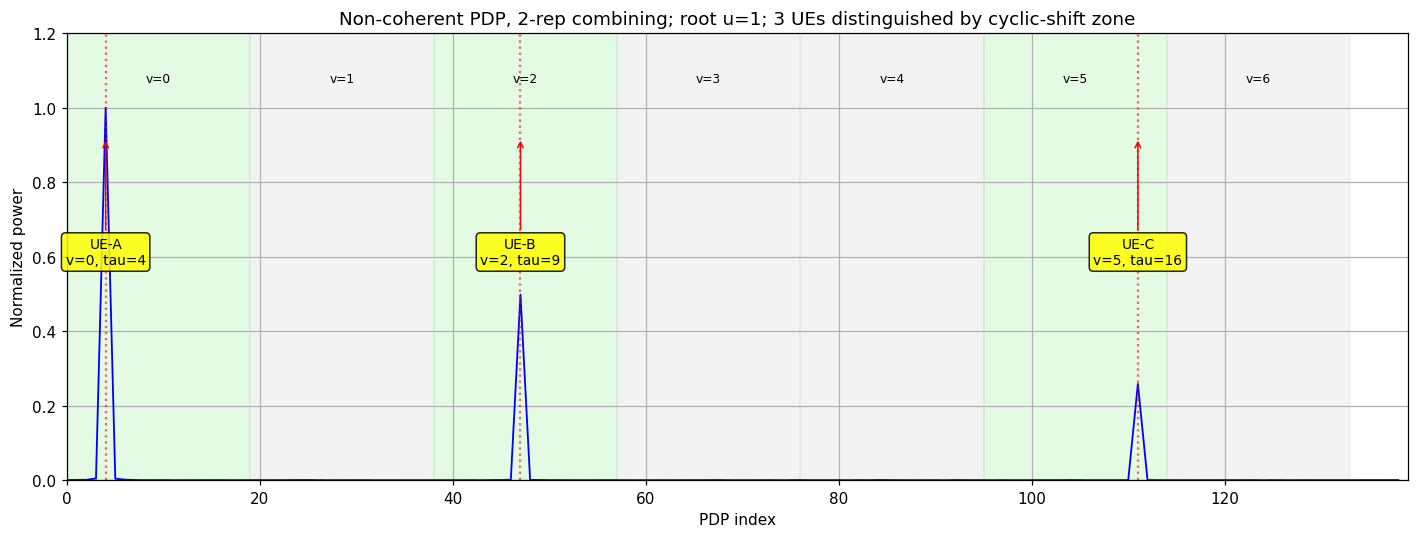

In [11]:
fig, ax = plt.subplots(figsize=(13, 5))
ues_for_plot = [{**ue, 'tau': ue['tau_lra']} for ue in ues]
plot_pdp_with_zones(pdp, N_CS, ues=ues_for_plot, ax=ax,
                    title=f'Non-coherent PDP, {N_REP}-rep combining; '
                          f'root u={u_root}; 3 UEs distinguished by cyclic-shift zone')
plt.tight_layout(); plt.show()

In [12]:
# Detection report: peak per zone, noise variance estimated from background.
nvar = estimate_noise_var(pdp, N_CS)
records = detect_peaks_per_zone(pdp, N_CS, threshold_ratio=20.0, noise_var=nvar)

print(f'noise_var estimate = {nvar:.4e}')
print(f'{"zone":<6}{"peak_idx":<11}{"tau_est":<9}{"snr_db":<10}{"detected"}')
for r in records:
    flag = 'YES' if r['detected'] else '-'
    print(f'  v={r["v"]:<4}{r["peak_idx"]:<11}{r["tau_est"]:<9}'
          f'{r["snr_db"]:<10.1f}{flag}')


noise_var estimate = 4.3488e-04
zone  peak_idx   tau_est  snr_db    detected
  v=0   4          4        36.5      YES
  v=1   25         6        4.1       -
  v=2   47         9        33.5      YES
  v=3   68         11       2.4       -
  v=4   76         0        3.7       -
  v=5   111        16       30.7      YES
  v=6   125        11       1.6       -


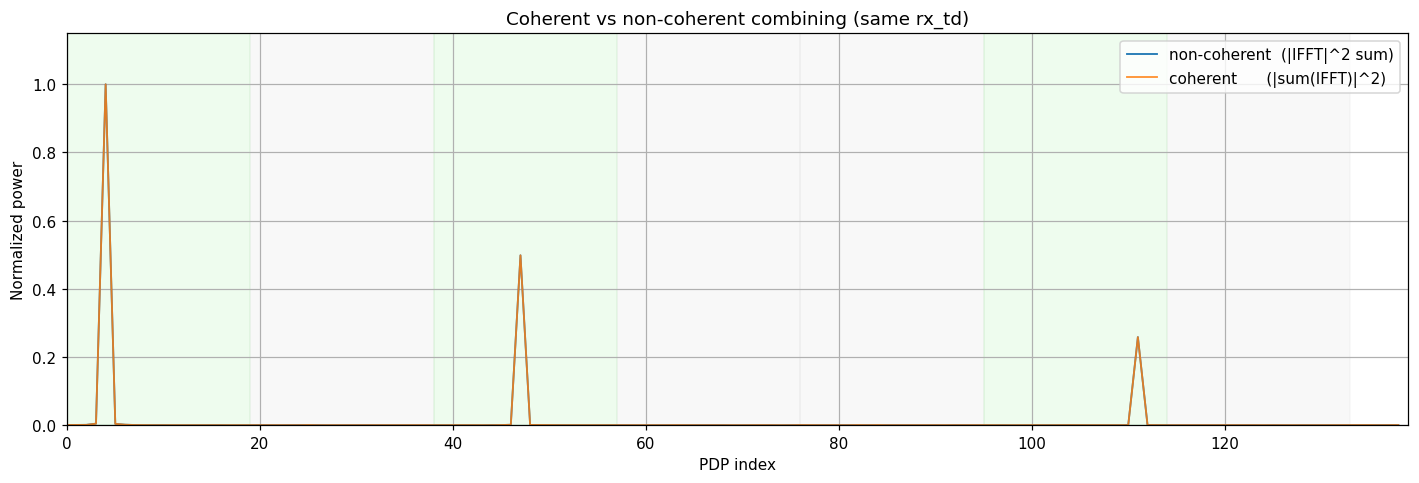

non-coherent  : peak/median = 5045.3
coherent      : peak/median = 9301.3


In [13]:
# ----- Coherent vs non-coherent combining -----
pdp_noncoh = prach_rx_pdp(rx, u_root=u_root, fmt='A1', n_fft=N_FFT, combine='noncoh')
pdp_coh = prach_rx_pdp(rx, u_root=u_root, fmt='A1', n_fft=N_FFT, combine='coh')

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(pdp_noncoh / pdp_noncoh.max(), label='non-coherent  (|IFFT|^2 sum)',
        linewidth=1.2)
ax.plot(pdp_coh / pdp_coh.max(),       label='coherent      (|sum(IFFT)|^2)',
        linewidth=1.2, alpha=0.85)
for z in range(L_RA // N_CS):
    ax.axvspan(z * N_CS, (z + 1) * N_CS,
               color='lightgreen' if z in {u['v'] for u in ues} else 'lightgray',
               alpha=0.15)
ax.set_xlim(0, L_RA); ax.set_ylim(0, 1.15)
ax.set_xlabel('PDP index'); ax.set_ylabel('Normalized power')
ax.set_title('Coherent vs non-coherent combining (same rx_td)')
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

# Peak / noise-floor metric to compare
for name, p in [('non-coherent', pdp_noncoh), ('coherent', pdp_coh)]:
    print(f'{name:<14}: peak/median = {p.max()/np.median(p):.1f}')


### 3.5 公共相位反补偿（论文 Section V-C，等式 14）

数据 DFE 链路对每个 OFDM 符号 $l$ 会施加 $e^{-i\theta_l}$ 的相位补偿，其中 $\theta_l = 2\pi f^{gNB}_0 (t^{\mu,s}_\text{start,l}+T^\mu_\text{CP,l})$，目的是支撑不同子载波频偏间的相干性。**PRACH 上行不做该补偿** —— 因此若数据/PRACH 共用宽带 FFT，并且想对 $N_\text{rep}$ 个 SEQ 做**相干合并**，必须把数据链上做的补偿在 PRACH 路径上反向消掉，否则不同 SEQ 之间相位不一致，相干积累退化。本模块的 `undo_common_phase` 给出该反向旋转的实现。

对**非相干合并**（前面 3.1–3.4 主线）公共相位反补偿可省，因为非相干合并对每 rep 的绝对相位不敏感。

频偏注记：FR2 假设残余频偏 $\xi\approx 4$ kHz，1 个 PRACH SEQ 时长 $T_\text{sym}=1/\Delta f_{RA}\approx 8.33\,\mu s$，引入的相位旋转 $\approx 2\pi\,\xi\,T_\text{sym} \approx 12°$ —— 在论文 V-D 末段被判定为"可忽略 (small enough to combine adjacent symbols)"。

### 3.6 数据 CP 去除带来的相位斜坡（论文 Section V-D，等式 15）

当 gNB 用宽带 FFT 同时解 PRACH 与 PUSCH（$\Delta f_\text{data}=\Delta f_{RA}$），FFT 窗口对齐到**数据 CP 末端**而非 PRACH aggregate CP 末端，PRACH 第 $j$ 次 SEQ 的 FFT 窗会向前漂移 $\rho_j$ 个样本（公式 15）：

$$\rho_j = \bmod\!\Big(\big(N^{RA}_{CP} - N^\mu_{CP,l}\big) - (j-1)\,N^\mu_{CP,l>0},\; N_{FFT}\Big)$$

频域上等效为对该 SEQ 抽出的 $L_{RA}$ tones 施加线性相位斜坡 $e^{i2\pi(n+k_2)\rho_j/N_{FFT}}$，$k_2 = K k_1 + \bar k + N_{FFT}/2$。下面用一个 mini 示例展示**补偿前/后**接收 PDP 的差异（人为引入 $\Delta_\text{cp}$ 个样本的 FFT 起点偏移）。


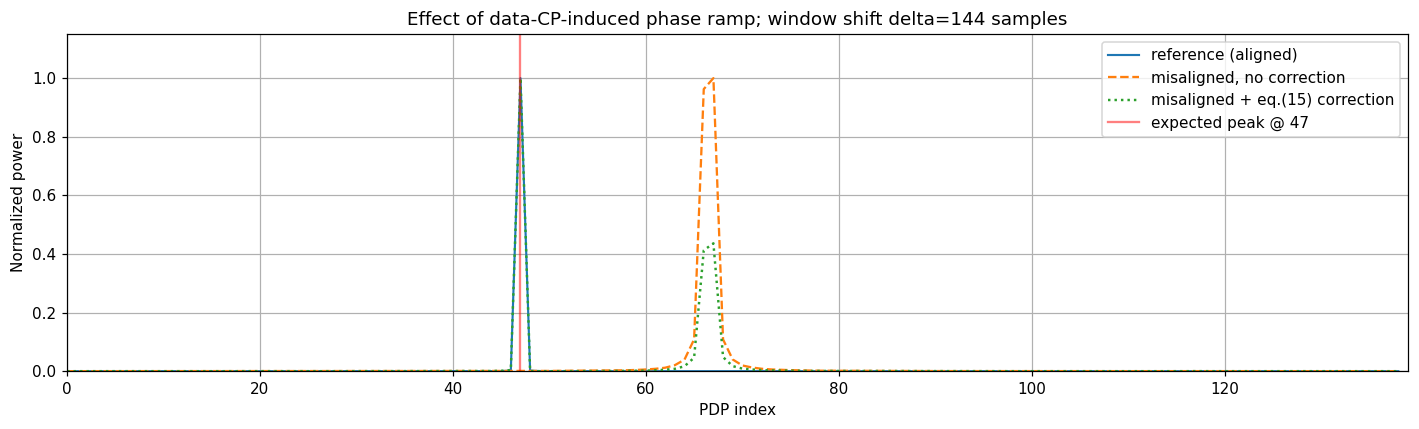

expected peak @ 47
argmax(ref)         = 47
argmax(no comp)     = 67
argmax(with comp)   = 47


In [14]:
# Demonstrate eq.(15) ramp compensation.
# Build a clean 2-rep PRACH waveform from a single UE, then deliberately
# misalign the FFT window by Delta_cp samples (FFT starts EARLY at the data CP
# instead of the PRACH aggregate CP) and compare PDPs with/without correction.
np.random.seed(13)
u_root_demo = 1
v_demo = 2
tau_demo = 66          # sample-rate samples -> within-zone PDP offset ~9
expected_peak = (v_demo * N_CS + round(tau_demo * L_RA / N_FFT)) % L_RA

tx_demo = prach_tx(u=u_root_demo, v=v_demo, fmt='A1', n_fft=N_FFT)
rx_demo = prach_channel([tx_demo], taus=[tau_demo], amps=[1.0], snr_db=25,
                        rng=np.random.default_rng(13))

# Reference: align FFT window to PRACH aggregate CP (correct)
pdp_ref = prach_rx_pdp(rx_demo, u_root=u_root_demo, fmt='A1', n_fft=N_FFT,
                       combine='coh')

# Inject window misalignment: FFT window starts EARLY by `delta` samples (as if
# aligned to N_CP_data instead of N_RA_CP). Equivalent to circularly shifting
# the received waveform RIGHT by delta samples before stripping N_RA_CP.
N_RA_CP = PRACH_FORMATS['A1']['N_cp']
N_CP_data = 144
delta = N_RA_CP - N_CP_data  # samples
rx_misaligned = np.concatenate([rx_demo[-delta:], rx_demo[:-delta]])

# Manually extract tones with the misaligned FFT window
k_start_demo = tone_start_index(N_FFT)
seq_tones = np.empty((N_REP, L_RA), dtype=complex)
body = rx_misaligned[N_RA_CP:N_RA_CP + N_REP * N_FFT]
for j in range(N_REP):
    seg = body[j * N_FFT:(j + 1) * N_FFT]
    seq_tones[j] = ofdm_demodulate(seg, N_FFT, cp_len=0,
                                   k_start=k_start_demo, n_tones=L_RA)

def pdp_from_tones(seq_tones, u_root, combine='coh'):
    root_fd = zc_fd(u_root, L_RA)
    corr = seq_tones * np.conj(root_fd)
    if combine == 'coh':
        return np.abs(np.fft.ifft(corr.sum(axis=0))) ** 2 / (L_RA ** 2)
    return np.sum(np.abs(np.fft.ifft(corr, axis=1)) ** 2, axis=0) / (L_RA ** 2)

pdp_no_comp = pdp_from_tones(seq_tones, u_root_demo, combine='coh')

# Apply eq.(15) ramp compensation
tones_comp = compensate_cp_phase_ramp(seq_tones, n_fft=N_FFT, k2=k_start_demo,
                                       N_RA_CP=N_RA_CP, N_CP_data=N_CP_data)
pdp_comp = pdp_from_tones(tones_comp, u_root_demo, combine='coh')

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(pdp_ref / pdp_ref.max(), label='reference (aligned)', linewidth=1.4)
ax.plot(pdp_no_comp / pdp_no_comp.max(), '--', label='misaligned, no correction')
ax.plot(pdp_comp / pdp_comp.max(), ':', label='misaligned + eq.(15) correction',
        linewidth=1.6)
ax.axvline(expected_peak, color='red', alpha=0.5,
           label=f'expected peak @ {expected_peak}')
ax.set_xlim(0, L_RA); ax.set_ylim(0, 1.15)
ax.set_xlabel('PDP index'); ax.set_ylabel('Normalized power')
ax.set_title(f'Effect of data-CP-induced phase ramp; '
             f'window shift delta={delta} samples')
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

print(f'expected peak @ {expected_peak}')
print(f'argmax(ref)         = {int(np.argmax(pdp_ref))}')
print(f'argmax(no comp)     = {int(np.argmax(pdp_no_comp))}')
print(f'argmax(with comp)   = {int(np.argmax(pdp_comp))}')

**结论 (Section 3)**：

- 在完整 OFDM 链路下，多个 UE 用同 root 不同 cyclic shift 时，BS 通过一个 $N_{FFT}$ FFT、一次共轭相乘、一次 $N_{IFFT}$ IFFT 就能同时区分多个 UE 并测出各自传播时延（peak 位置 = $C_v+\tau$）。
- **相干合并** 在峰值/噪底比上明显优于 **非相干合并**，但需要先做 V-C / V-D 两步相位补偿（残余频偏 < 4 kHz 时 V-C 影响有限）。
- 数据 CP 与 PRACH 聚合 CP 长度不一致时（共用宽带 FFT 的常见场景），公式 (15) 的相位斜坡补偿不可省 —— 仿真显示补偿后峰位回到正确位置。
- 检测门限基于估计的噪声方差，比写死的 `0.1*pdp.max()` 在低 SNR 下更可靠。


## 4. 多频域 occasion 仿真

**场景**：$M=2$ 个 FD occasions 在频率上相邻。6 个 UE 分两组，**各组内** 用同一 root 的不同 cyclic shift 同时接入，组之间使用不同的 FD occasion。

| Group | FD occasion | Root | cyclic shifts (v) | UEs |
|-------|-------------|------|-------------------|-----|
| 1     | FD#0        | u=1  | {0, 2, 5}         | UE-A1, UE-B1, UE-C1 |
| 2     | FD#1        | u=1  | {1, 3, 6}         | UE-A2, UE-B2, UE-C2 |

两组在频率上不重叠，BS 对两个 FD occasion **独立**处理。仿真中两个 FD 在频率上相隔 17.28 MHz（$L_{RA}\Delta f_{RA}$ + 守护），但因为接收链对每个 FD 独立做 N_FFT FFT 后只抽取自己那段 tones，效果上等于两条并行的 PRACH 接收链 —— 这里用相同的 `prach_rx_pdp` 复用即可。


In [15]:
# tau values are at sample rate (fs=122.88 Msps); within-zone PDP offsets shown
# in the comment correspond to round(tau * L_RA / N_FFT).
scenarios = [
    {'fd': 0, 'u': 1, 'ues': [
        {'name': 'UE-A1', 'v': 0, 'tau':  37, 'amp': 1.0},   # offset  5
        {'name': 'UE-B1', 'v': 2, 'tau':  81, 'amp': 0.8},   # offset 11
        {'name': 'UE-C1', 'v': 5, 'tau': 125, 'amp': 0.6},   # offset 17
    ]},
    {'fd': 1, 'u': 1, 'ues': [
        {'name': 'UE-A2', 'v': 1, 'tau':  52, 'amp': 0.9},   # offset  7
        {'name': 'UE-B2', 'v': 3, 'tau':  96, 'amp': 0.7},   # offset 13
        {'name': 'UE-C2', 'v': 6, 'tau':  15, 'amp': 0.5},   # offset  2
    ]},
]

def simulate_fd(scn, snr_db=10, seed=None):
    rng = np.random.default_rng(seed)
    tx_list = [prach_tx(u=scn['u'], v=ue['v'], fmt='A1', n_fft=N_FFT)
               for ue in scn['ues']]
    taus = [ue['tau'] for ue in scn['ues']]
    amps = [ue['amp'] for ue in scn['ues']]
    rx = prach_channel(tx_list, taus, amps, snr_db=snr_db, rng=rng)
    return prach_rx_pdp(rx, u_root=scn['u'], fmt='A1', n_fft=N_FFT,
                        combine='noncoh')

for scn in scenarios:
    for ue in scn['ues']:
        ue['tau_lra'] = round(ue['tau'] * L_RA / N_FFT)

pdps = [simulate_fd(scn, snr_db=10, seed=11 + i) for i, scn in enumerate(scenarios)]
print('Per-FD PDP shape:', [p.shape for p in pdps])

Per-FD PDP shape: [(139,), (139,)]


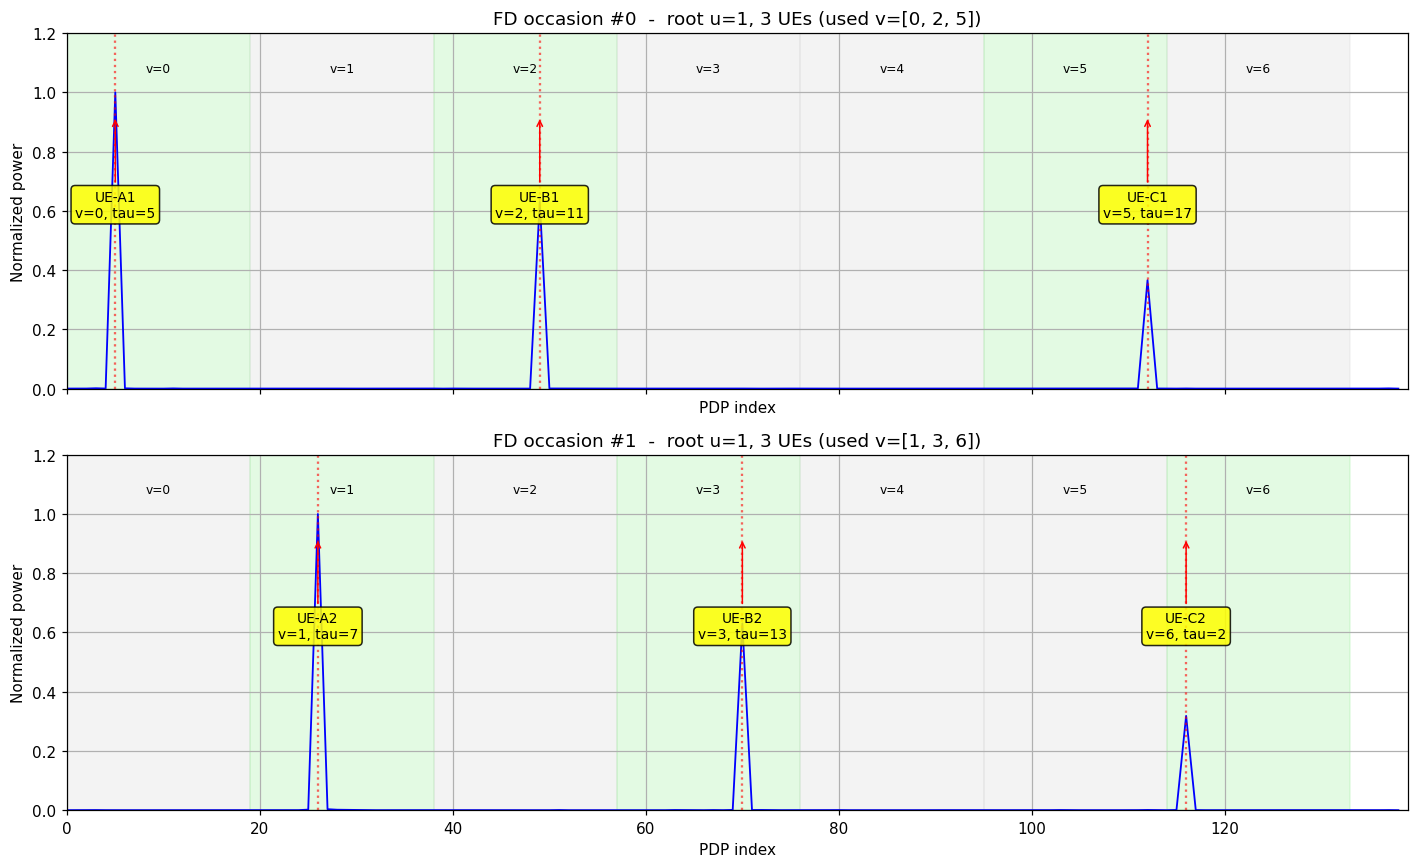

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
for ax, scn, pdp in zip(axes, scenarios, pdps):
    ues_for_plot = [{**ue, 'tau': ue['tau_lra']} for ue in scn['ues']]
    plot_pdp_with_zones(pdp, N_CS, ues=ues_for_plot, ax=ax,
                        title=f"FD occasion #{scn['fd']}  -  root u={scn['u']}, "
                              f"3 UEs (used v={[u['v'] for u in scn['ues']]})")
axes[1].set_xlabel('PDP index'); axes[1].set_xlim(0, L_RA)
plt.tight_layout(); plt.show()

In [17]:
# Per-FD detection report
for scn, pdp in zip(scenarios, pdps):
    nvar = estimate_noise_var(pdp, N_CS)
    print(f"\nFD occasion #{scn['fd']} (root u={scn['u']}, noise_var={nvar:.3e}):")
    for r in detect_peaks_per_zone(pdp, N_CS, threshold_ratio=20.0,
                                    noise_var=nvar):
        if r['detected']:
            print(f'  zone v={r["v"]}: peak @ idx {r["peak_idx"]} '
                  f'(tau_est={r["tau_est"]}), SNR={r["snr_db"]:.1f} dB')



FD occasion #0 (root u=1, noise_var=5.642e-04):
  zone v=0: peak @ idx 5 (tau_est=5), SNR=35.5 dB
  zone v=2: peak @ idx 49 (tau_est=11), SNR=33.5 dB
  zone v=5: peak @ idx 112 (tau_est=17), SNR=31.1 dB

FD occasion #1 (root u=1, noise_var=2.678e-04):
  zone v=1: peak @ idx 26 (tau_est=7), SNR=37.8 dB
  zone v=3: peak @ idx 70 (tau_est=13), SNR=35.8 dB
  zone v=6: peak @ idx 116 (tau_est=2), SNR=32.8 dB


**要点回顾 (Section 4)**：

1. **频率上彼此独立**：两个 FD occasion 不重叠，独立处理；每个 FD occasion 独立支持最多 $\lfloor L_{RA}/N_{CS}\rfloor=7$ 个 cyclic shifts。
2. **容量倍增**：$M$ 个 FD occasion → 同 PRACH slot 内承载量 ×M；$M\in\{1,2,4,8\}$ 由 RRC `msg1-FDM` 控制。
3. **接入选择**：UE 根据测得的 SSB 索引 / RSRP 决定使用哪个 RACH occasion (TD + FD)。每个 SSB 通过 RRC 映射关系（论文 Section III/IV 详述）对应到一个或多个 PRACH occasion 子集。
4. **gNB 实现复杂度**：每 FD occasion 一次 $N_{FFT}$ FFT，每 root 一次 $N_{IFFT}$ IFFT；总计 $M \times \text{(roots)} \times \text{(TD occasions)} \times \text{(antennas)}$ 次 IFFT —— PRACH 接收机的硬件瓶颈（论文 Section VI-A）。

---

## 总结

| 概念 | 物理意义 | 仿真验证 |
|------|----------|----------|
| ZC 频域恒包络 | OFDM 时域 PAPR 低 | Section 1.1 PAPR ≈ 3 dB |
| 同 root, 不同 cyclic shift 正交 | 多 UE 共享同一 occasion, 零互扰 | Section 1.2(a) + Section 3 |
| 不同 root 互相关 $1/\sqrt{L_{RA}}$ | 同 cell 多 root 共存的本底干扰水平 | Section 1.2(b) |
| cyclic shift = 时延偏移 | gNB 通过 PDP 峰值位置直接测时延 | Section 1.3, 3, 4 |
| 完整 OFDM 链路 + tone 提取 (k₁/k̄) | TX 链路与 38.211 等式 (12) 对齐 | Section 3 主线 |
| 相干 vs 非相干合并 | 相干 SNR 增益大但需相位补偿 | Section 3 |
| 公共相位反补偿 (V-C 等式 14) | 数据 DFE 旋转不能带入 PRACH | Section 3.5 公式 |
| 数据 CP 相位斜坡补偿 (V-D 等式 15) | 共用宽带 FFT 时对齐 | Section 3.6 |
| Cell-dimensioning 四步流程 | N_CS / Cv / roots / radius 一致 | Section 2.3 重现 Table 2 |
| TD/FD occasion + cyclic shift | 三维资源使 PRACH 容量灵活可扩 | Section 4 |
